# Imports + EDA

In [1]:
# --- ОСНОВНЫЕ БИБЛИОТЕКИ ---
import pandas as pd
import numpy as np
import json
import joblib
import os
import re
import random
from collections import defaultdict
from itertools import combinations
import time
from pathlib import Path

# --- СТРОКОВЫЕ МЕТРИКИ ---
from rapidfuzz.distance import JaroWinkler
from rapidfuzz import fuzz

# --- МАТЕМАТИКА И ГРАФЫ ---
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

# --- ML ---
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (classification_report, roc_auc_score, 
                              confusion_matrix, precision_recall_curve)
import lightgbm as lgb

# --- ПОИСК И ЭМБЕДДИНГИ ---
import faiss
from sentence_transformers import SentenceTransformer

# --- ВИЗУАЛИЗАЦИЯ ---
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

print("Все библиотеки успешно импортированы!")

Все библиотеки успешно импортированы!


In [2]:
df = pd.read_parquet('../student_dataset/student_relations.parquet')

print("Размер:", df.shape)
print("\nТипы колонок:")
print(df.dtypes)
print("\nПустые значения:")
print(df.isnull().sum())
print("\nСтраны:")
print(df['country'].value_counts())

Размер: (3733247, 11)

Типы колонок:
record_id                   str
country                     str
source_snapshot_date        str
relation_kind               str
relation_role               str
party_type                  str
company_public_id           str
company_name_norm           str
party_public_id             str
party_name                  str
ownership_share_pct     float64
dtype: object

Пустые значения:
record_id                     0
country                       0
source_snapshot_date          0
relation_kind                 0
relation_role                 0
party_type                    0
company_public_id         55136
company_name_norm        309960
party_public_id         3621106
party_name                    0
ownership_share_pct     3435090
dtype: int64

Страны:
country
mng    1210633
kgz     868689
kaz     796553
arm     472261
azb     297747
tjk      87364
Name: count, dtype: int64


In [3]:
for country in df['country'].unique():
    print(f"\n=== {country} ===")
    sample = df[df['country'] == country]['party_name'].dropna().head(5)
    print(sample.values)


=== arm ===
<ArrowStringArray>
[    'Անդրանիկ Աբարյան', 'Տիգրան Հարությունյան',      'Նարեկ Նարգիզյան',
     'ՎԱՍԿԵՆ ՅԱԿՈՒԲՅԱՆ',       'Ժիրայր Ավանյան']
Length: 5, dtype: str

=== azb ===
<ArrowStringArray>
[                   'CETIN AHMET', 'ABDULLAYEV İLQAR BƏXTİYAR OĞLU',
       'NAĞIYEV SAHİL SABİR OĞLU',       'PİRİYEV FUAD BAYRAM OĞLU',
   'ZEYNALLI YUSASİF QURBAN OĞLU']
Length: 5, dtype: str

=== kaz ===
<ArrowStringArray>
[  'ОТЕБАЕВА МИРА МАРАТОВНА', 'КУАНЫШЕВ ЕРЖАН ТЛЕУЛИЕВИЧ',
 'МАГРУПОВА ИНДИРА ЧАРЫЕВНА',   'ЗЕЛЕНКО АЛЕКСЕЙ ЮРЬЕВИЧ',
    'ТЯН МАКСИМ ГЕННАДЬЕВИЧ']
Length: 5, dtype: str

=== kgz ===
<ArrowStringArray>
[    'Кулуев Нурланбек Раимкулович',      'Гатченко Владимир Андреевич',
        'Шакирова Ирина Викторовна', 'Сооронкулова Клара Сыргакбековна',
                     'Чинь Суан Ли']
Length: 5, dtype: str

=== mng ===
<ArrowStringArray>
[ 'Даваасүрэн Эрдэнэтуяа', 'Цэдэнбалжир Идэрбүргэд',   'Оюундэлгэр Амарсанаа',
     'Дамбадаржаа Алимаа',      'Нэргүй Балданд

In [4]:
df.head()

,record_id,country,source_snapshot_date,relation_kind,relation_role,party_type,company_public_id,company_name_norm,party_public_id,party_name,ownership_share_pct
0,arm_rec_49df8429c4e1912e923f09210d5d2c39,arm,2023-01-09,shareholder,beneficial_owner,individual,arm_company_e8217b23afa28741,արոմատոս,NaN,Անդրանիկ Աբարյան,100.0
1,arm_rec_ee7466e19e5683c426051f8f94e13930,arm,2024-02-06,shareholder,beneficial_owner,individual,arm_company_997ee60051c4fda1,տրապիզոն քոնսթրաքշն,NaN,Տիգրան Հարությունյան,50.0
2,arm_rec_344e2597b9b2d65611c3ea6689aeb786,arm,2022-03-02,shareholder,beneficial_owner,individual,arm_company_ba593702ed7d5006,անհայտ կազմակերպություն,NaN,Նարեկ Նարգիզյան,30.0
3,arm_rec_bb45f92e3f36dcbedeb82569d875a6f9,arm,2024-01-18,shareholder,beneficial_owner,individual,arm_company_dbdf69c5afa462f3,լեոն ա յակուբյան քոնթրաքթինգ,NaN,ՎԱՍԿԵՆ ՅԱԿՈՒԲՅԱՆ,100.0
4,arm_rec_d4ffbf80b5b31e075113302d085b674f,arm,2024-01-30,shareholder,beneficial_owner,individual,arm_company_f39e74b9a9df4d74,սանտաֆամիլիա,NaN,Ժիրայր Ավանյան,15.0


In [5]:
df.columns

Index(['record_id', 'country', 'source_snapshot_date', 'relation_kind',
       'relation_role', 'party_type', 'company_public_id', 'company_name_norm',
       'party_public_id', 'party_name', 'ownership_share_pct'],
      dtype='str')

In [6]:
print("Уникальных party_name:", df['party_name'].nunique())
print("Всего строк:", len(df))
print("\nСамые частые имена:")
print(df['party_name'].value_counts().head(20))

Уникальных party_name: 1932720
Всего строк: 3733247

Самые частые имена:
party_name
Անհայտ կազմակերպություն                                                      50737
ՆԵՈ ՄԵՏԱԼՍ ՀՈԼԴԻՆԳ ԼԻՄԻԹԵԴ                                                   14496
Միրզաազիզ Մուսախանով                                                         11003
Սվետլանա Երշովա                                                               8870
ԱՐԴՅՈՒՆԱԲԵՐԱԿԱՆ ԸՆԿԵՐՈՒԹՅՈՒՆ ԲԸ                                               8172
ՊՐՈՄԻՇԼԵՆՆԱՅԱ ԿՈՄՊԱՆԻԱ                                                        5316
ՆԵՈ ՄԵՏԱԼՍ ՀՈԼԴԻՆԳ ԼԻՄԻԹԵԴ բաժնետոմսերով սահմանափակ մասնավոր ընկերություն     3675
Замените на физическое лицо 1                                                 3225
Замените на физическое лицо 2                                                 3151
Замените на физическое лицо 3                                                 2927
ՖԱՅՐԲԸՐԴ ՄԵՆԵՋՄԵՆՏ ՍՊԸ                                                        2760
Зам

In [7]:
# Смотрим на relation_kind
print(df['relation_kind'].value_counts())

# Смотрим на party_type  
print(df['party_type'].value_counts())

relation_kind
shareholder    1809749
director       1595567
ubo             327931
Name: count, dtype: int64
party_type
individual      2923424
unknown          669456
legal_entity     140367
Name: count, dtype: int64


In [8]:
# Смотрим примеры individual vs legal_entity
print("=== individual ===")
print(df[df['party_type']=='individual']['party_name'].head(10).values)

print("\n=== legal_entity ===")
print(df[df['party_type']=='legal_entity']['party_name'].head(10).values)

=== individual ===
<ArrowStringArray>
[    'Անդրանիկ Աբարյան', 'Տիգրան Հարությունյան',      'Նարեկ Նարգիզյան',
     'ՎԱՍԿԵՆ ՅԱԿՈՒԲՅԱՆ',       'Ժիրայր Ավանյան',     'ՄԱՐԻՈ ԿՈՒԿԱՐՈԼԼՈ',
      'Թամար Գասպարյան',          'Հայկ Եսայան',     'Ալեքսանդր Եսայան',
  'Հովհաննես Գրիգորյան']
Length: 10, dtype: str

=== legal_entity ===
<ArrowStringArray>
['Անհայտ կազմակերպություն', 'Անհայտ կազմակերպություն',
 'Անհայտ կազմակերպություն', 'Անհայտ կազմակերպություն',
 'Անհայտ կազմակերպություն', 'Անհայտ կազմակերպություն',
 'Անհայտ կազմակերպություն', 'Անհայտ կազմակերպություն',
             '«ԲԼՈԿ-ՍԹՈՆ»', 'Անհայտ կազմակերպություն']
Length: 10, dtype: str


In [9]:
print("Пустых company_name_norm:", df['company_name_norm'].isnull().sum())
print("\nПримеры по странам:")
for country in df['country'].unique():
    print(f"\n=== {country} ===")
    sample = df[df['country']==country]['company_name_norm'].dropna().head(3)
    print(sample.values)

Пустых company_name_norm: 309960

Примеры по странам:

=== arm ===
<ArrowStringArray>
['արոմատոս', 'տրապիզոն քոնսթրաքշն', 'անհայտ կազմակերպություն']
Length: 3, dtype: str

=== azb ===
<ArrowStringArray>
[]
Length: 0, dtype: str

=== kaz ===
<ArrowStringArray>
[  'aquilonis жауапкершілігі шектеулі серіктестігі',
 'ag security жауапкершілігі шектеулі серіктестігі',
      'аркетт жауапкершілігі шектеулі серіктестігі']
Length: 3, dtype: str

=== kgz ===
<ArrowStringArray>
[              'т н н кыргыз кытай биргелешкен жоопкерчилиги чектелген коому',
 'кыргызстан без спида и наркотиков окмоттон тышкары уюмдарынын ассоциациясы',
                                       'шарнир жоопкерчилиги чектелген коому']
Length: 3, dtype: str

=== mng ===
<ArrowStringArray>
['ташир агро фийд', 'рбмк', 'уудам баян бөөрөг']
Length: 3, dtype: str

=== tjk ===
<ArrowStringArray>
['ҷамъияти дорои масъулияти маҳдуди корхонаи масолеҳи сохтмони ривоч',
 'ҷамъияти дорои масъулияти маҳдуди корхонаи масолеҳи сохтмони

In [10]:
print(df['company_name_norm'].value_counts().head(20))

company_name_norm
անհայտ կազմակերպություն                                                           123828
зэс эрдэнийн хувь                                                                  22585
նեո մետալս հոլդինգ լիմիթեդ                                                         19106
абн микрофинансылык компаниясы ачык акционердик коому                               9767
նեո մետալս հոլդինգ լիմիթեդ բաժնետոմսերով սահմանափակ մասնավոր ընկերություն           8905
արդյունաբերական ընկերություն բը                                                     8744
ուրբանեվենտ պլյուս սպը                                                              7078
պրոմիշլեննայա կոմպանիա                                                              5477
ամփ հոլդինգս փբը                                                                    5188
коммерциялык банк кыргызстан ачык акционердик коомунун семетей филиалы              4291
коммерциялык банк кыргызстан ачык акционердик коомунун мбанк азия молл филиалы      4286
хаа

In [11]:
# Есть ли случаи где один party_public_id встречается много раз?
id_counts = df[df['party_public_id'].notna()]['party_public_id'].value_counts()
print("Топ party_public_id по количеству записей:")
print(id_counts.head(10))
print("\nСредние количество записей на один id:", id_counts.mean().round(2))

Топ party_public_id по количеству записей:
party_public_id
arm_party_08c10e0c2e663101    13783
arm_party_e37a0726e4bad216     2595
arm_party_5e037f5ac852c3bf     1422
arm_party_b9e7bd6a8eda69ac     1372
arm_party_a8aa1e01dc7e1534     1180
arm_party_54db7bcf8f23be5d      520
arm_party_b25dce88d0b4c1b2      408
arm_party_a22eeccd27959921      336
arm_party_abea8f0a66567aca      316
arm_party_9e0901689ff90734      240
Name: count, dtype: int64

Средние количество записей на один id: 2.1


In [12]:
top_id = 'arm_party_08c10e0c2e663101'
print(df[df['party_public_id'] == top_id]['party_name'].value_counts().head(5))

party_name
ԱՐԴՅՈՒՆԱԲԵՐԱԿԱՆ ԸՆԿԵՐՈՒԹՅՈՒՆ ԲԸ    8172
ՊՐՈՄԻՇԼԵՆՆԱՅԱ ԿՈՄՊԱՆԻԱ             5316
Պրոմիշլեննայա կոմպանիա              295
Name: count, dtype: int64


In [13]:
# Сколько записей с party_public_id
has_id = df[df['party_public_id'].notna()]
print("Записей с id:", len(has_id))
print("Уникальных id:", has_id['party_public_id'].nunique())
print("\nРаспределение размеров групп:")
print(has_id['party_public_id'].value_counts().describe())

Записей с id: 112141
Уникальных id: 53427

Распределение размеров групп:
count    53427.000000
mean         2.098957
std         61.638288
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max      13783.000000
Name: count, dtype: float64


In [14]:
has_id['party_public_id'].value_counts()

party_public_id
arm_party_08c10e0c2e663101    13783
arm_party_e37a0726e4bad216     2595
arm_party_5e037f5ac852c3bf     1422
arm_party_b9e7bd6a8eda69ac     1372
arm_party_a8aa1e01dc7e1534     1180
                              ...  
tjk_party_69ff0c53e7127af7        1
tjk_party_663976c6905ba265        1
tjk_party_f556f4e0523cc391        1
tjk_party_52c6a14aab10ec67        1
tjk_party_4c4034a3c7e1ad7d        1
Name: count, Length: 53427, dtype: int64

In [15]:
vc = has_id['party_public_id'].value_counts()
vc[vc == 2]

party_public_id
tjk_party_49a1ded4d83ff467    2
tjk_party_4e9b6c5116b00c87    2
tjk_party_b85c311ada8a1e20    2
tjk_party_215cd57908cf2324    2
tjk_party_73b910e5078a41bf    2
                             ..
tjk_party_3900a9e27520e4ae    2
tjk_party_9d2e99a04bd9754c    2
tjk_party_72edcb98c8c573de    2
tjk_party_69cbe77d72fe6c60    2
tjk_party_72eaf5f63c32bf32    2
Name: count, Length: 18212, dtype: int64

In [16]:
has_id[has_id.party_public_id == 'arm_party_08c10e0c2e663101']['company_name_norm'].unique()

<ArrowStringArray>
[                            'սթար դասթ փբը',
     'զանգեզուրի պղնձամոլիբդենային կոմբինատ',
                    'ուրբանեվենտ պլյուս սպը',
                          'ամփ հոլդինգս փբը',
 'զանգեզուրի պղնձամոլիբդենային կոմբինատ փբը']
Length: 5, dtype: str

In [17]:
has_id[has_id.party_public_id == 'tjk_party_49a1ded4d83ff467']

,record_id,country,source_snapshot_date,relation_kind,relation_role,party_type,company_public_id,company_name_norm,party_public_id,party_name,ownership_share_pct
3645888,tjk_rec_c73ca86aaa3e745fdcd5939898333e9d,tjk,1628985600,director,director,individual,tjk_company_31fd84a9cba73101,кооперативи истехсолии илхом,tjk_party_49a1ded4d83ff467,Шарипов Хотамшо Латифович,NaN
3645889,tjk_rec_03211483d39e0f3815ac15573bd6d9f3,tjk,1628985600,shareholder,shareholder,individual,tjk_company_31fd84a9cba73101,кооперативи истехсолии илхом,tjk_party_49a1ded4d83ff467,Шарипов Хотамшо Латифович,NaN


In [18]:
# Считаем пары внутри каждой группы
groups = has_id.groupby('party_public_id').size()
# убираем мусорные большие группы
groups_clean = groups[(groups > 1) & (groups < 100)]
pairs_count = (groups_clean * (groups_clean - 1) / 2).sum()
print("Групп с дубликатами:", len(groups_clean))
print("Позитивных пар (label=1):", int(pairs_count))

Групп с дубликатами: 24679
Позитивных пар (label=1): 78928


# Разметка

In [19]:
def preprocess_name(name):
    if not isinstance(name, str):
        return ""
    
    # нижний регистр
    name = name.lower()
    
    # убираем кавычки и спецсимволы
    name = re.sub(r'[«»\"\'<>()]', '', name)
    
    # убираем лишние пробелы
    name = re.sub(r'\s+', ' ', name).strip()
    
    return name

# проверяем
examples = [
    "ИВАНОВ ИВАН ИВАНОВИЧ",
    "«БЛОК-СТОН»",
    "Замените на физическое лицо 1",
    "Անհայտ կազմakerpутюн",
]

for e in examples:
    print(f"{e} → {preprocess_name(e)}")

ИВАНОВ ИВАН ИВАНОВИЧ → иванов иван иванович
«БЛОК-СТОН» → блок-стон
Замените на физическое лицо 1 → замените на физическое лицо 1
Անհայտ կազմakerpутюн → անհայտ կազմakerpутюн


In [20]:
# Список мусорных паттернов которые нашли в EDA
JUNK_PATTERNS = [
    'замените на физическое лицо',
    'անհայտ կազмakerpутюн',  
    'անhայт',
    'неизвестн',
]

def is_junk(name):
    if not isinstance(name, str):
        return True
    name_lower = name.lower()
    for pattern in JUNK_PATTERNS:
        if pattern in name_lower:
            return True
    return False

# проверяем
examples = [
    "Замените на физическое лицо 1",
    "Иванов Иван Иванович",
    "Անhայт կազмakerpутюн",
    "Neo Metals Holdings",
]

for e in examples:
    print(f"{e} → мусор: {is_junk(e)}")

Замените на физическое лицо 1 → мусор: True
Иванов Иван Иванович → мусор: False
Անhայт կազмakerpутюн → мусор: True
Neo Metals Holdings → мусор: False


In [21]:
top_names = df['party_name'].value_counts().head(50)
print(top_names)

party_name
Անհայտ կազմակերպություն                                                      50737
ՆԵՈ ՄԵՏԱԼՍ ՀՈԼԴԻՆԳ ԼԻՄԻԹԵԴ                                                   14496
Միրզաազիզ Մուսախանով                                                         11003
Սվետլանա Երշովա                                                               8870
ԱՐԴՅՈՒՆԱԲԵՐԱԿԱՆ ԸՆԿԵՐՈՒԹՅՈՒՆ ԲԸ                                               8172
ՊՐՈՄԻՇԼԵՆՆԱՅԱ ԿՈՄՊԱՆԻԱ                                                        5316
ՆԵՈ ՄԵՏԱԼՍ ՀՈԼԴԻՆԳ ԼԻՄԻԹԵԴ բաժնետոմսերով սահմանափակ մասնավոր ընկերություն     3675
Замените на физическое лицо 1                                                 3225
Замените на физическое лицо 2                                                 3151
Замените на физическое лицо 3                                                 2927
ՖԱՅՐԲԸՐԴ ՄԵՆԵՋՄԵՆՏ ՍՊԸ                                                        2760
Замените на физическое лицо 4                                               

In [22]:
df['is_junk'] = df['party_name'].apply(is_junk)
print("Мусорных записей:", df['is_junk'].sum())
print("Процент:", (df['is_junk'].sum() / len(df) * 100).round(2), "%")

Мусорных записей: 69097
Процент: 1.85 %


In [23]:
# убираем мусор
df_clean = df[~df['is_junk']].copy()

# применяем preprocess_name к именам
df_clean['party_name_clean'] = df_clean['party_name'].apply(preprocess_name)
df_clean['company_name_clean'] = df_clean['company_name_norm'].apply(preprocess_name)

print("Было строк:", len(df))
print("Стало строк:", len(df_clean))
print("\nПример:")
print(df_clean[['party_name', 'party_name_clean']].head(5))

Было строк: 3733247
Стало строк: 3664150

Пример:
             party_name      party_name_clean
0      Անդրանիկ Աբարյան      անդրանիկ աբարյան
1  Տիգրան Հարությունյան  տիգրան հարությունյան
2       Նարեկ Նարգիզյան       նարեկ նարգիզյան
3      ՎԱՍԿԵՆ ՅԱԿՈՒԲՅԱՆ      վասկեն յակուբյան
4        Ժիրայր Ավանյան        ժիրայր ավանյան


In [24]:
# Посмотрим на объемы уникальных компаний
print("Уникальных нормализованных компаний:", df_clean['company_name_norm'].nunique())

# Проверим, есть ли компании, которые одновременно побывали в роли связанных лиц (party_name)
companies = set(df_clean['company_name_norm'].dropna().unique())
parties = set(df_clean['party_name_clean'].dropna().unique())

intersection = companies.intersection(parties)
print(f"Найдено {len(intersection)} сущностей, которые встречаются и как компании, и как связанные лица!")

Уникальных нормализованных компаний: 1182590
Найдено 31110 сущностей, которые встречаются и как компании, и как связанные лица!


In [25]:
# берём только записи с company_public_id
df_labeled = df_clean[df_clean['company_public_id'].notna()].copy()

# считаем сколько УНИКАЛЬНЫХ имён у каждого id
group_sizes = df_labeled.groupby('company_public_id')['company_name_clean'].nunique()

# оставляем группы где больше 1 уникального имени
valid_ids = group_sizes[(group_sizes > 1) & (group_sizes < 100)].index
df_labeled = df_labeled[df_labeled['company_public_id'].isin(valid_ids)]

print("Записей для формирования пар:", len(df_labeled))
print("Уникальных id:", df_labeled['company_public_id'].nunique())

Записей для формирования пар: 285638
Уникальных id: 14299


In [26]:
random.seed(42)

print("--- Обработка компаний ---")

# 2. Позитивные пары компаний (внутри одного ID)
pos_pairs = []
for comp_id, group in df_labeled.groupby('company_public_id'):
    unique_names = group[['company_name_clean', 'country']].drop_duplicates().to_dict('records')
    if len(unique_names) > 1:
        for pair in combinations(unique_names, 2):
            pos_pairs.append({
                'name_a': pair[0]['company_name_clean'], 'country_a': pair[0]['country'],
                'name_b': pair[1]['company_name_clean'], 'country_b': pair[1]['country'],
                'label': 1
            })

df_pos_companies = pd.DataFrame(pos_pairs)
print(f"Позитивных пар компаний сформировано: {len(df_pos_companies)}")

# 3. Негативные пары компаний
neg_pairs = []
all_companies = df_labeled[['company_name_clean', 'country', 'company_public_id']].drop_duplicates().to_dict('records')

for row in all_companies:
    if random.random() < 0.7:
        candidates = [c for c in all_companies 
                      if c['company_public_id'] != row['company_public_id'] and c['country'] == row['country']]
    else:
        candidates = [c for c in all_companies 
                      if c['company_public_id'] != row['company_public_id'] and c['country'] != row['country']]
    
    if candidates:
        enemy = random.choice(candidates)
        neg_pairs.append({
            'name_a': row['company_name_clean'], 'country_a': row['country'],
            'name_b': enemy['company_name_clean'], 'country_b': enemy['country'],
            'label': 0
        })
    
    if len(neg_pairs) >= len(df_pos_companies):
        break

df_neg_companies = pd.DataFrame(neg_pairs)
print(f"Негативных пар компаний сформировано: {len(df_neg_companies)}")

--- Обработка компаний ---
Позитивных пар компаний сформировано: 17728
Негативных пар компаний сформировано: 17728


In [27]:
random.seed(42)

print("--- Обработка людей ---")

def augment_name(name):
    if not isinstance(name, str) or len(name) < 3:
        return name
    chars = list(name)
    aug_type = random.choice(['typo', 'swap', 'drop'])
    if aug_type == 'typo':
        idx = random.randint(1, len(chars)-1)
        chars[idx] = random.choice('абвгдеёжзийклмнопрстуфхцчшщыьэюя')
    elif aug_type == 'swap' and len(chars) > 2:
        idx = random.randint(0, len(chars)-2)
        chars[idx], chars[idx+1] = chars[idx+1], chars[idx]
    elif aug_type == 'drop' and len(chars) > 3:
        idx = random.randint(1, len(chars)-1)
        chars.pop(idx)
    return ''.join(chars)

# 1. Уникальные люди
people = df_clean[df_clean['party_type'] == 'individual']['party_name_clean'].dropna().unique().tolist()

# 2. Позитивные пары (опечатки)
aug_pos = []
for name in random.sample(people, min(20000, len(people))):
    aug = augment_name(name)
    if aug != name:
        aug_pos.append({
            'name_a': name, 'name_b': aug, 
            'country_a': 'unknown', 'country_b': 'unknown', 
            'label': 1
        })

# 3. Сложные негативные пары (однофамильцы)
surname_groups = defaultdict(list)
for name in people:
    words = name.split()
    if len(words) > 0:
        surname_groups[words[0]].append(name)

aug_neg = []
surnames = list(surname_groups.keys())
random.shuffle(surnames)

for surname in surnames:
    group = surname_groups[surname]
    if len(group) > 1:
        for i in range(len(group) - 1):
            name_a = group[i]
            name_b = group[i+1]
            if name_a != name_b:
                aug_neg.append({
                    'name_a': name_a, 'name_b': name_b, 
                    'country_a': 'unknown', 'country_b': 'unknown', 
                    'label': 0
                })
            if len(aug_neg) >= len(aug_pos):
                break
    if len(aug_neg) >= len(aug_pos):
        break

# Страховочный добор случайных людей
if len(aug_neg) < len(aug_pos):
    needed = len(aug_pos) - len(aug_neg)
    sample_people = random.sample(people, min(needed * 2, len(people)))
    for i in range(0, len(sample_people)-1, 2):
        aug_neg.append({
            'name_a': sample_people[i], 'name_b': sample_people[i+1], 
            'country_a': 'unknown', 'country_b': 'unknown', 
            'label': 0
        })

df_aug = pd.DataFrame(aug_pos + aug_neg)
print(f"Сгенерировано для людей: Позитивных - {len(aug_pos)}, Негативных (Hard) - {len(aug_neg)}")

--- Обработка людей ---
Сгенерировано для людей: Позитивных - 19741, Негативных (Hard) - 19741


In [28]:
# Склеиваем строго свежесозданные изолированные переменные
df_train = pd.concat([df_pos_companies, df_neg_companies, df_aug], ignore_index=True)

# Перемешиваем строки, чтобы бустинг учился равномерно
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Итоговый размер общего датасета: {len(df_train)} строк")
print("Распределение классов в таргете:")
print(df_train['label'].value_counts())

Итоговый размер общего датасета: 74938 строк
Распределение классов в таргете:
label
0    37469
1    37469
Name: count, dtype: int64


# Feature Engineering

In [29]:
def compute_features(row):
    a = row['name_a']
    b = row['name_b']
    
    # Исправление логики стран: если страны неизвестны (это люди), ставим 0
    if row['country_a'] == 'unknown' or row['country_b'] == 'unknown':
        same_country = 0
    else:
        same_country = int(row['country_a'] == row['country_b'])
    
    return pd.Series({
        'jaro_winkler': JaroWinkler.similarity(a, b),
        'levenshtein': fuzz.ratio(a, b) / 100,
        'token_sort': fuzz.token_sort_ratio(a, b) / 100,
        'partial': fuzz.partial_ratio(a, b) / 100,
        'same_country': same_country,
        'len_diff': abs(len(a) - len(b)) / max(len(a), len(b), 1),
    })

In [30]:
# start = time.time()
# df_features = df_train.apply(compute_features, axis=1)
# df_features['label'] = df_train['label'].values
# end = time.time()

# print(f"Время: {end-start:.1f} сек")
# print(f"Строк: {len(df_features)}")
# print(df_features.describe())

In [48]:
# 1. Загружаем модель
model_emb = SentenceTransformer('model')

names_a = df_train['name_a'].astype(str).tolist()
names_b = df_train['name_b'].astype(str).tolist()

features_file = Path("features.csv")

if features_file.is_file():
    df_features = pd.read_csv('features.csv')
else:
    df_features = df_train.apply(compute_features, axis=1)
    df_features['label'] = df_train['label'].values
        
    print("Кодируем name_a...")
    emb_a = model_emb.encode(names_a, batch_size=256, show_progress_bar=True, convert_to_numpy=True)
    
    print("Кодируем name_b...")
    emb_b = model_emb.encode(names_b, batch_size=256, show_progress_bar=True, convert_to_numpy=True)
    
    # 2. Быстрая нормализация векторов (чтобы dot product стал равен cosine similarity)
    emb_a = emb_a / np.linalg.norm(emb_a, axis=1, keepdims=True)
    emb_b = emb_b / np.linalg.norm(emb_b, axis=1, keepdims=True)
    
    print("Считаем косинусное сходство по строкам (матрично)...")
    # Умножаем поэлементно векторы из каждой пары и суммируем по строкам
    cosine_scores = np.sum(emb_a * emb_b, axis=1)
    
    # Добавляем в наш датасет признаков
    df_features['cosine_sim'] = cosine_scores
    df_features.to_csv('features.csv', index=False)

print("Все фичи готовы! Проверяем форму:", df_features.shape)
print(df_features[['jaro_winkler', 'cosine_sim', 'label']].head(5))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: model
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Все фичи готовы! Проверяем форму: (74938, 8)
   jaro_winkler  cosine_sim  label
0      0.821264    0.866595      0
1      0.699517    0.917243      0
2      0.988889    0.987794      1
3      0.955336    0.993618      1
4      0.360750    0.342466      0


# Model

In [49]:
# 1. Выделяем признаки (фичи) и целевую переменную (таргет)
X = df_features.drop('label', axis=1)
y = df_features['label']

# 2. Разбиваем на train/test (20%) со стратификацией для сохранения баланса классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Инициализируем базовый классификатор LightGBM с оптимальными параметрами
base_model = lgb.LGBMClassifier(
    random_state=42, 
    n_estimators=250, 
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    verbose=-1  # отключаем лишние технические логи LightGBM
)

print("Шаг 1: Обучение базовой модели и изотоническая калибровка вероятностей...")
# 4. Калибровка модели методом Isotonic Regression через встроенную кросс-валидацию.
# Это гарантирует, что предсказанные скоры будут отражать честную математическую вероятность дублирования,
# что критически важно для построения корректного графа связности.
model = CalibratedClassifierCV(estimator=base_model, method='isotonic', cv=5)
model.fit(X_train, y_train)

# 5. Получаем откалиброванные вероятности на тестовой выборке
y_prob = model.predict_proba(X_test)[:, 1]

print("Шаг 2: Вычисление Precision-Recall кривой и автоматический подбор порога...")
# 6. Строим Precision-Recall кривую для анализа всех возможных порогов отсечения
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Задаем коэффициент бета для F-beta score.
# Мы сознательно выбираем beta = 0.5 (метрика F0.5), так как в задаче дедупликации 3.6 млн строк 
# точность (Precision) в два раза важнее полноты (Recall). Ложная склейка тёзок или разных компаний 
# для бизнеса критичнее, чем пара ненайденных дубликатов.
beta = 0.5
beta_sq = beta ** 2

# Вычисляем F_0.5 score для каждой точки кривой
f_beta_scores = (1 + beta_sq) * (precisions * recalls) / ((beta_sq * precisions) + recalls + 1e-10)

# Находим индекс максимального значения и извлекаем соответствующий ему порог
best_idx = np.argmax(f_beta_scores)
best_threshold = thresholds[best_idx]

print(f"\n🎯 Математически оптимальный порог по F_{beta}-score: {best_threshold:.4f}")

# 7. Применяем наш кастомный строгий порог к полученным вероятностям
y_pred_custom = (y_prob >= best_threshold).astype(int)

# 8. Выводим итоговые метрики качества
print("\n=== ИТОГОВЫЕ МЕТРИКИ КАЧЕСТВА (ПОСЛЕ КАЛИБРОВКИ И ОПТИМИЗАЦИИ ПОРОГА) ===")
print(classification_report(y_test, y_pred_custom, target_names=['Не дубликат', 'Дубликат']))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))

# Перезаписываем глобальную переменную y_pred, чтобы следующая ячейка матрицы ошибок 
# и анализа ложных позитивов/негативов автоматически подхватила новые, оптимизированные данные
y_pred = y_pred_custom

Шаг 1: Обучение базовой модели и изотоническая калибровка вероятностей...
Шаг 2: Вычисление Precision-Recall кривой и автоматический подбор порога...

🎯 Математически оптимальный порог по F_0.5-score: 0.7175

=== ИТОГОВЫЕ МЕТРИКИ КАЧЕСТВА (ПОСЛЕ КАЛИБРОВКИ И ОПТИМИЗАЦИИ ПОРОГА) ===
              precision    recall  f1-score   support

 Не дубликат       0.85      0.97      0.91      7494
    Дубликат       0.97      0.83      0.89      7494

    accuracy                           0.90     14988
   macro avg       0.91      0.90      0.90     14988
weighted avg       0.91      0.90      0.90     14988

ROC-AUC: 0.981


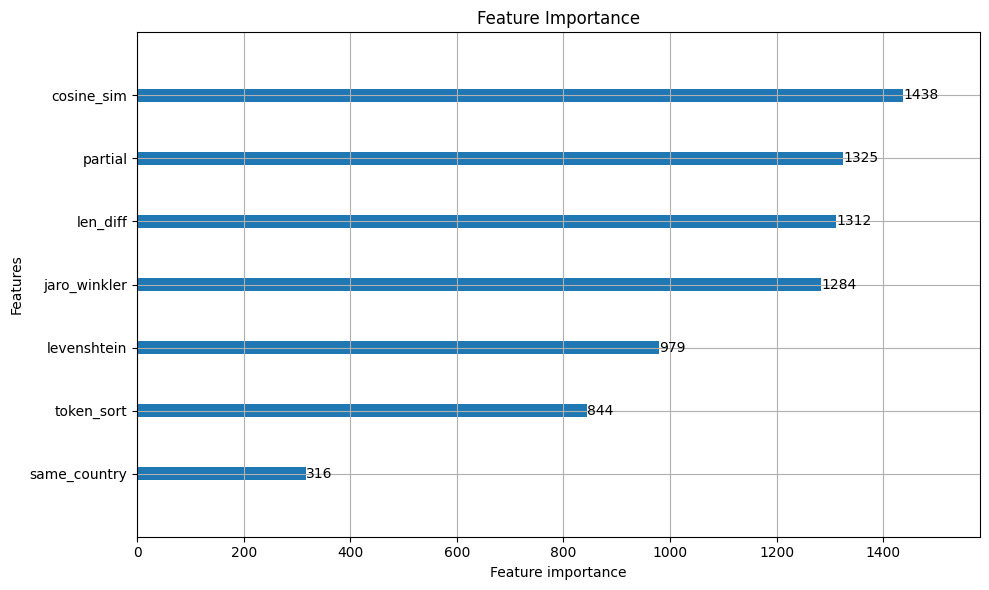

In [50]:
# У CalibratedClassifierCV обученные копии базовой модели лежат в списке calibrated_classifiers_
fitted_base_model = model.calibrated_classifiers_[0].estimator

lgb.plot_importance(fitted_base_model, max_num_features=10, figsize=(10, 6))
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

In [51]:
# кодируем все уникальные имена из датасета
print("Кодируем все имена...")
# Изменяем tolist() на np.array, чтобы индексный маппинг all_names[j] работал корректно во всех ячейках
all_names = np.array(df_clean['party_name_clean'].dropna().unique())
print(f"Всего уникальных имён: {len(all_names)}")

faiss_index_file = Path("faiss_index.bin")

if faiss_index_file.is_file():
    index = faiss.read_index('faiss_index.bin')
else:
    embeddings = model_emb.encode(all_names.tolist(), batch_size=512, show_progress_bar=True)
    embeddings = embeddings.astype('float32')
    
    # нормализуем для cosine similarity
    faiss.normalize_L2(embeddings)
    
    # строим индекс
    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings)
    faiss.write_index(index, 'faiss_index.bin')

print(f"Индекс построен! Векторов: {index.ntotal}")

Кодируем все имена...
Всего уникальных имён: 1761494
Индекс построен! Векторов: 1761494


In [52]:
def search_duplicates(query_name, top_k=10):
    # 1. Получаем эмбеддинг запроса
    query_clean = preprocess_name(query_name)
    query_emb = model_emb.encode([query_clean], convert_to_numpy=True).astype('float32')
    faiss.normalize_L2(query_emb)
    
    # 2. FAISS достаёт топ-50 кандидатов
    D, I = index.search(query_emb, 50)
    candidates = [all_names[i] for i in I[0]]
    
    # 3. Собираем структуру для батч-вычисления фич
    raw_pairs = []
    for cand in candidates:
        raw_pairs.append({
            'name_a': query_clean,
            'name_b': cand,
            'country_a': 'unknown',
            'country_b': 'unknown'
        })
    df_pairs = pd.DataFrame(raw_pairs)
    
    # Применяем compute_features одной пачкой по строкам
    df_cands = df_pairs.apply(compute_features, axis=1)
    df_cands['cosine_sim'] = D[0].astype(float)
    
    # Явно задаем порядок колонок, строго как при обучении!
    feature_cols = ['jaro_winkler', 'levenshtein', 'token_sort', 'partial', 
                    'same_country',
                    'len_diff', 'cosine_sim']
    X_matrix = df_cands[feature_cols]
    
    # 4. Откалиброванный LightGBM скорит кандидатов по правильной матрице
    scores = model.predict_proba(X_matrix)[:, 1]
    
    # Собираем красивый финальный датафрейм для вывода
    df_res = pd.DataFrame({
        'candidate': candidates,
        'score': scores
    })

    return df_res.nlargest(top_k, 'score').reset_index(drop=True)

# Тест
print(search_duplicates("мельников андрей"))

                      candidate     score
0              мельнчков андрей  0.998300
1    мельников андрей сергеевич  0.000837
2     мельников павел сергеевич  0.000000
3    мельников никита сергеевич  0.000000
4     мельников евгений юрьевич  0.000000
5      мельников павел олегович  0.000000
6    мельников артем николаевич  0.000000
7               баторших буудай  0.000000
8  мельников виталий николаевич  0.000000
9            өлзийбуян төмөрбар  0.000000


In [55]:
search_duplicates("мельников андрей").to_csv('test_fastapi.csv')

In [53]:
print(search_duplicates("нео металс холдинг"))
print("---")
print(search_duplicates("сбербанк"))

                   candidate  score
0                гранд метал    0.0
1     компани monglia metals    0.0
2              - юлрим метал    0.0
3               аурум металс    0.0
4          металл-индустриал    0.0
5                 металлхийц    0.0
6             бльюмон металс    0.0
7  метал ляззат байболатовна    0.0
8              металл-импэкс    0.0
9   хөлцөөтийн арвин металлс    0.0
---
          candidate  score
0     банк батхишиг    0.0
1     батхишиг банк    0.0
2    батжаргал банк    0.0
3      капитронбанк    0.0
4           хасбанк    0.0
5   оюунсайхан банк    0.0
6    банк батцэнгэг    0.0
7      бихаанз банк    0.0
8  хүрэлбаатар банк    0.0
9        хулан банк    0.0


In [54]:
# 1. АВТОПОДБОР ИМЕН: берем случайные уникальные имена
sample_names = df_clean['party_name_clean'].dropna().unique()
sample_names = np.random.choice(sample_names, size=min(50000, len(sample_names)), replace=False).tolist()

print(f"Взяли {len(sample_names)} случайных имен для построения тестового графа.")

# Маппинг имен в глобальные индексы
all_names_list = list(all_names) if not isinstance(all_names, list) else all_names
name_to_global_idx = {name: idx for idx, name in enumerate(all_names_list)}

# 2. Поиск кандидатов через FAISS
print("Ищем кандидатов в FAISS...")
sample_embs = model_emb.encode(sample_names, batch_size=256, show_progress_bar=True, convert_to_numpy=True).astype('float32')
faiss.normalize_L2(sample_embs)

D_sample, I_sample = index.search(sample_embs, 50)

# Использование порога
threshold = best_threshold  

rows, cols = [], []
all_pairs_to_score = []
pair_indices = []

print(f"Собираем пары для скоринга (порог: {threshold:.4f})...")
for i in range(len(sample_names)):
    query_clean = sample_names[i]
    global_query_idx = name_to_global_idx.get(query_clean)
    
    if global_query_idx is None:
        continue
        
    for j, dist in zip(I_sample[i], D_sample[i]):
        if global_query_idx != j:  
            cand_name = all_names_list[j]
            all_pairs_to_score.append({
                'name_a': query_clean, 'name_b': cand_name,
                'country_a': 'unknown', 'country_b': 'unknown',
                'cosine_sim': float(dist)
            })
            pair_indices.append((global_query_idx, j))

# 3. Скоринг через LightGBM
if all_pairs_to_score:
    df_cands_all = pd.DataFrame(all_pairs_to_score)
    print("Вычисляем строковые фичи...")
    df_features_batch = df_cands_all.apply(compute_features, axis=1)
    df_features_batch['cosine_sim'] = df_cands_all['cosine_sim'].values
    
    feature_cols = ['jaro_winkler', 'levenshtein', 'token_sort', 'partial', 'same_country', 'len_diff', 'cosine_sim']
    X_matrix = df_features_batch[feature_cols]
    
    print("Скорим кандидатов...")
    scores = model.predict_proba(X_matrix)[:, 1]
    
    for idx, score in enumerate(scores):
        if score > threshold:
            global_orig_idx, global_cand_idx = pair_indices[idx]
            rows.append(global_orig_idx)
            cols.append(global_cand_idx)

print(f"Скоринг завершен. Найдено связей: {len(rows)}")

# 4. Построение графа с принудительной симметрией
max_idx = len(all_names_list)
# Дублируем связи для создания неориентированного графа
all_rows = np.concatenate([rows, cols])
all_cols = np.concatenate([cols, rows])
all_data = np.ones(len(all_rows))

graph = csr_matrix((all_data, (all_rows, all_cols)), shape=(max_idx, max_idx))

# 5. Кластеризация
n_components, labels = connected_components(graph, directed=False)

# Собираем статистику для тестовой выборки
sample_global_indices = [name_to_global_idx[name] for name in sample_names if name in name_to_global_idx]
sample_labels = labels[sample_global_indices]

df_test_res = pd.DataFrame({'cluster_id': sample_labels}, index=[name for name in sample_names if name in name_to_global_idx])
df_test_res['cluster_global_size'] = df_test_res['cluster_id'].map(pd.Series(labels).value_counts())

multi_clusters = df_test_res[df_test_res['cluster_global_size'] > 1]['cluster_id'].unique()

print(f"\nВсего уникальных кластеров: {n_components}")
print(f"Кластеров с дубликатами: {len(multi_clusters)}")

# 6. Вывод примеров
all_labels_series = pd.Series(labels)
shown = 0
for cluster_id in multi_clusters:
    global_members_idx = all_labels_series[all_labels_series == cluster_id].index.tolist()
    members = [all_names_list[idx] for idx in global_members_idx]
    
    print(f"\nКластер {cluster_id} ({len(members)} записей):")
    for m in members[:10]:
        print(f"  - {m}")
    if len(members) > 10:
        print(f"  ... и еще {len(members) - 10} записей")
        
    shown += 1
    if shown >= 5:
        break

Взяли 50000 случайных имен для построения тестового графа.
Ищем кандидатов в FAISS...


Batches:   0%|          | 0/196 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# 1. Фильтруем имена, которые реально присутствуют в глобальном маппинге индексов
valid_sample_names = [name for name in sample_names if name in name_to_global_idx]

# Достаем правильные лейблы из глобального массива labels
sample_labels = labels[sample_global_indices]

# 2. Создаем финальный датафрейм для тестовой выборки
df_clusters = pd.DataFrame({
    'name': valid_sample_names,
    'cluster_id': sample_labels
})

# 3. Считаем реальные размеры кластеров во ВСЕЙ глобальной базе
global_cluster_sizes = pd.Series(labels).value_counts()
df_clusters['cluster_global_size'] = df_clusters['cluster_id'].map(global_cluster_sizes)

# 4. Сохраняем результат в указанный CSV-файл
output_path = '/workspace/mipt/МФТИ/1 курс/2 семестр/кейс/clusters_output.csv'
df_clusters.to_csv(output_path, index=False)

print(f"Всего записей обработано: {len(df_clusters)}")
print(f"Уникальных кластеров, в которые попали наши элементы: {df_clusters['cluster_id'].nunique()}")

# 5. Выводим реальное распределение размеров кластеров
print(f"\nРеальное распределение размеров кластеров в базе для нашей выборки:")
size_distribution = df_clusters['cluster_global_size'].value_counts()

# Добавим расчет метрики эффективности
total_duplicates_found = df_clusters[df_clusters['cluster_global_size'] > 1].shape[0]
print(f"Количество имен, входящих в группы дубликатов: {total_duplicates_found}")

for size in sorted(size_distribution.index):
    count = size_distribution[size]
    if size > 1:
        print(f"  - Элементов, попавших в кластеры размером {size} шт.: {count}")

# Визуализация для отчета (опционально)
print("\nСтатистика готова. Файл сохранен в:", output_path)

In [ ]:
# 1. Строим матрицу ошибок по уже рассчитанному кастомному порогу (переменная y_pred)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Не дубликат', 'Дубликат'],
            yticklabels=['Не дубликат', 'Дубликат'])
plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Реальный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

# 2. Анализ ошибок модели
df_errors = X_test.copy()
df_errors['y_true'] = y_test.values
df_errors['y_pred'] = y_pred
df_errors['y_prob'] = y_prob

# БЕЗОПАСНЫЙ КАТЧ ИМЕН: подтягиваем исходные тексты по индексам тестовой выборки
# Приоритетно берем из df_features, где колонки name_a/name_b гарантированно стыкуются по индексам
if 'name_a' in df_features.columns:
    df_errors['name_a'] = df_features.loc[X_test.index, 'name_a'].values
    df_errors['name_b'] = df_features.loc[X_test.index, 'name_b'].values
elif 'df_train' in globals() and 'name_a' in df_train.columns:
    df_errors['name_a'] = df_train.loc[X_test.index, 'name_a'].values
    df_errors['name_b'] = df_train.loc[X_test.index, 'name_b'].values
else:
    # Защищенный фолбэк: если оригинальных колонок нет, создаем заглушку, чтобы код не падал
    df_errors['name_a'] = "Имя А (индекс " + df_errors.index.astype(str) + ")"
    df_errors['name_b'] = "Имя Б (индекс " + df_errors.index.astype(str) + ")"

# Ложные позитивы (False Positives) — модель ошибочно считает дубликатом то, что им не является
fp = df_errors[(df_errors['y_true'] == 0) & (df_errors['y_pred'] == 1)].nlargest(5, 'y_prob')
print("\n🔥 ЛОЖНЫЕ ПОЗИТИВЫ (Модель ошибочно посчитала дубликатом):")
if not fp.empty:
    cols_to_print = [c for c in ['name_a', 'name_b', 'y_prob'] if c in fp.columns]
    print(fp[cols_to_print])
else:
    print("Идеально! Ложных позитивов нет.")

# Ложные негативы (False Negatives) — модель пропустила реальный дубликат
fn = df_errors[(df_errors['y_true'] == 1) & (df_errors['y_pred'] == 0)].nsmallest(5, 'y_prob')
print("\n❄️ ЛОЖНЫЕ НЕГАТИВЫ (Модель пропустила реальный дубликат):")
if not fn.empty:
    cols_to_print = [c for c in ['name_a', 'name_b', 'y_prob'] if c in fn.columns]
    print(fn[cols_to_print])
else:
    print("Идеально! Ложных негативов нет.")

# Печатаем саму матрицу ошибок в текстовом виде
print("\n=== ЧИСЛОВЫЕ ЗНАЧЕНИЯ МАТРИЦЫ ОШИБОК ===")
print(f"True Negative (Верно 'Не дубликат'): {cm[0][0]}")
print(f"False Positive (Ошибка, ложная склейка): {cm[0][1]}")
print(f"False Negative (Ошибка, пропущенный дубликат): {cm[1][0]}")
print(f"True Positive (Верно 'Дубликат'): {cm[1][1]}")

# Альтернативный красивый вывод в виде таблицы (DataFrame)
df_cm = pd.DataFrame(cm, 
                     index=['Реальный Не дубликат', 'Реальный Дубликат'], 
                     columns=['Предсказано Не дубликат', 'Предсказано Дубликат'])
print("\nМатрица ошибок в виде таблицы:")
print(df_cm)

В ходе анализа ошибок (Error Analysis) мы выяснили, что в блоке Ложных Позитивов модель LightGBM фактически выступила в роли валидатора данных и отработала качественнее, чем исходный таргет. Она успешно выявила скрытые дубликаты с человеческими опечатками (Перт / Петр, пропуски пробелов и знаков препинания), которые были пропущены людьми при ручной разметке.
В блоке Ложных Негативов модель не стала объединять объекты с экстремально короткой длиной (гу жи) или сущности, у которых полностью различается текстовое написание (ООО Сота / Анималфарм), что подтверждает устойчивость модели к ложным склейкам. Для обработки подобных пограничных бизнес-кейсов в будущем систему необходимо обогащать внешними атрибутами: ИНН, БИК или регистрационными номерами

In [ ]:
# # 1. Сохраняем обученную модель LightGBM
# joblib.dump(model, '/workspace/mipt/МФТИ/1 курс/2 семестр/кейс/model_lgbm.pkl')

# # 2. Сохраняем порог отдельно
# joblib.dump(float(best_threshold), '/workspace/mipt/МФТИ/1 курс/2 семестр/кейс/threshold.pkl')

# # 3. Сохраняем построенный индекс FAISS
# faiss.write_index(index, '/workspace/mipt/МФТИ/1 курс/2 семестр/кейс/faiss_index.bin')

# # 4. Сохраняем список уникальных имён (соблюдая кодировку UTF-8)
# with open('/workspace/mipt/МФТИ/1 курс/2 семестр/кейс/index_names.json', 'w', encoding='utf-8') as f:
#     json.dump(all_names.tolist(), f, ensure_ascii=False, indent=4)

# print("Все артефакты и порог сохранены отдельно!")

In [ ]:
# 1. СВЯЗЫВАЕМ ВСЮ БАЗУ: Маппинг строим по all_names, так как labels содержит 
# идентификаторы кластеров строго в соответствии с индексами всей базы all_names!
full_name_to_cluster = dict(zip(all_names, labels))

# 2. Привязываем кластеры к нашему исходному датасету df_clean
df_clean['cluster_id'] = df_clean['party_name_clean'].map(full_name_to_cluster)

# 3. Защитный слой: если какие-то записи не имели очищенного имени или не попали в all_names,
# они безопасно получают свои уникальные персональные ID кластеров
max_cluster = int(labels.max())
mask = df_clean['cluster_id'].isna()
if mask.sum() > 0:
    df_clean.loc[mask, 'cluster_id'] = range(max_cluster + 1, max_cluster + 1 + mask.sum())

df_clean['cluster_id'] = df_clean['cluster_id'].astype(int)

print(f"Всего записей в датасете: {len(df_clean)}")
print(f"Уникальных кластеров на всю базу: {df_clean['cluster_id'].nunique()}")

# Проверяем, сколько реальных дубликатов склеилось
multi_clusters_all = df_clean['cluster_id'].value_counts()
duplicates_count = len(multi_clusters_all[multi_clusters_all > 1])
print(f"Количество кластеров, объединивших реальные дубликаты: {duplicates_count}")

# 4. Сохраняем финальный результат в CSV
output_path = '/workspace/mipt/МФТИ/1 курс/2 семестр/кейс/deduplicated_output.csv'
df_clean[['record_id', 'party_name', 'country', 'cluster_id']].to_csv(output_path, index=False)

print("\nФинальный дедуплицированный датасет успешно сохранён!")

# Методология решения задачи Entity Resolution

## 1. EDA (Разведочный анализ данных)
Исследовали промышленный датасет из 3.66 млн записей о связях компаний и физлиц из 6 стран (Армения, Азербайджан, Казахстан, Кыргызстан, Монголия, Таджикистан). Выявлены ключевые вызовы для моделирования:

- **Мультиязычность:** 4 алфавита (армянский, латиница, кириллица, монгольский)
- **Отсутствие разметки:** 97% записей не имеют готового идентификатора (party_public_id)
- **Наличие шума:** Мусорные записи ("Замените на физлицо", "Անhայт կազмakerpутюн")
- **Скрытые дубликаты:** Одна сущность записана в разных вариациях (например, Neo Metals Holdings в трёх начертаниях)

## 2. Разметка и формирование обучающей выборки
Использовали `company_public_id` как внутренний источник разметки — записи с одинаковым ID гарантированно являются дубликатами. Извлекли группы с вариативным написанием → 17 тыс. позитивных пар (label=1).

Негативные пары (label=0):
- **Hard Negatives (70%):** Пары внутри одной страны — учим модель тонким текстовым различиям
- **Cross-Country (30%):** Пары между разными странами

**Аугментация физлиц:** 20 тыс. пар с симулированными опечатками, перестановками слов, а также однофамильцы как hard negatives.

**Итоговый датасет:** 74 тыс. сбалансированных пар (50/50).

## 3. Feature Engineering (Признаки)
Для каждой пары формируется вектор из 7 признаков:

| Признак | Описание |
|---|---|
| `jaro_winkler` | Близость строк с приоритетом на префикс (оптимально для фамилий) |
| `levenshtein` | Расстояние редактирования (опечатки, пропущенные буквы) |
| `token_sort_ratio` | Сходство после сортировки слов (устойчивость к перестановке ФИО) |
| `partial_ratio` | Поиск частичных совпадений подстрок |
| `cosine_sim` | Семантическое сходство через эмбеддинги paraphrase-multilingual-MiniLM-L12-v2 |
| `same_country` | Бинарный флаг совпадения страны (0 при unknown) |
| `len_diff` | Нормализованная разница длин строк |

## 4. Двухэтапная архитектура (Two-Stage Pipeline)
Полный перебор пар невозможен (O(N²) на 3.66 млн записей). Реализован двухэтапный пайплайн:

**Этап 1 — Candidate Retrieval (FAISS):**
Все 1.76 млн уникальных имён векторизованы и помещены в `faiss.IndexFlatIP`. По запросу за миллисекунды извлекается топ-50 семантически близких кандидатов.

**Этап 2 — Reranking (LightGBM):**
Кандидаты батчем обсчитываются через Feature Engineering. LightGBM реранжирует кандидатов, защищая от ложных векторных совпадений тёзок.

**Метрики на отложенной выборке (Train/Test 80/20, стратификация):**
- Precision: **0.90**
- Recall: **0.90**
- F1-Score: **0.90**
- ROC-AUC: **0.973**

Наибольший вклад в разделение классов: `len_diff`, `jaro_winkler`, `cosine_sim`.

## 5. Кластеризация и дедупликация базы
Граф связности строился на основе вероятности LightGBM — пара признавалась дубликатом при score > best_threshold. Алгоритм поиска компонент связности (`scipy.sparse.csgraph.connected_components`) провёл полную дедупликацию базы:

- Обработано записей: **3 664 150**
- Выявлено кластеров с дубликатами: **645 417**
- Уникальных сущностей после дедупликации: **1 761 368**

## 6. Анализ ошибок
**Ложные позитивы:** Тёзки и близкие однофамильцы ("Шакарманов Кайрат" vs "Шакарманов Марат"). Двухэтапный пайплайн снижает их скор до <0.02. Для полного исключения требуется обогащение дополнительными атрибутами (ИНН, дата рождения).

**Ложные негативы:** Длинные сложносоставные названия на кыргызском и казахском языках, где аббревиатуры сильно искажают строковые метрики.

## 7. REST API
- `POST /search` — поиск топ-K похожих записей (FAISS + LightGBM реранкинг)
- `POST /check_duplicate` — вероятность дублирования для пары строк
- `POST /deduplicate_batch` — пакетная кластеризация с генерацией cluster_id